Loading datasets...

--- TASK 1A: Dataset Visualization ---
30-sec dataset shape: (1000, 61) (Samples: 1000, Dimensions: 58)
3-sec dataset shape: (9990, 61) (Samples: 9990, Dimensions: 58)


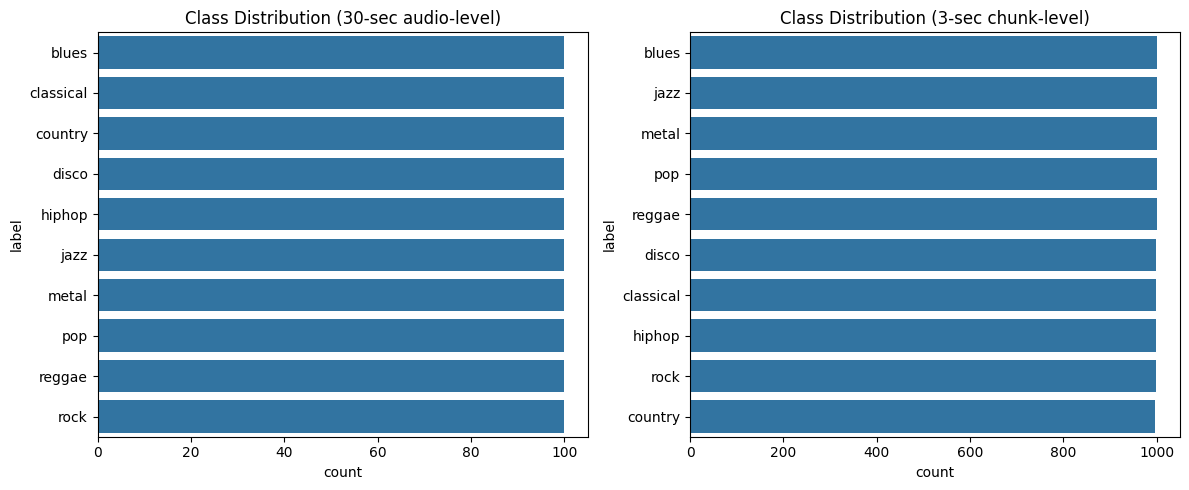


--- TASK 1B & 1C: Training on 30-second features ---

Results for Random Forest on 30-sec Data:
Classification Accuracy: 0.6700
Macro F1-score: 0.6676


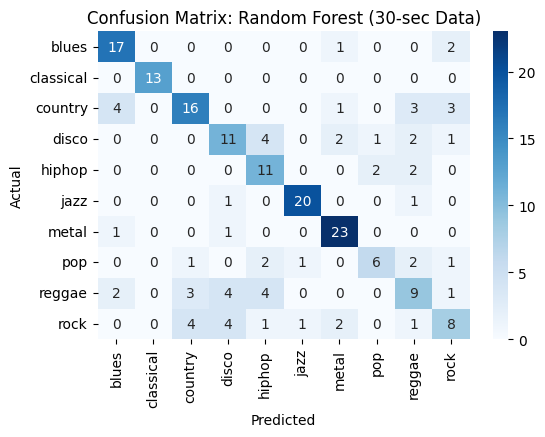


Results for SVM on 30-sec Data:
Classification Accuracy: 0.7000
Macro F1-score: 0.7006


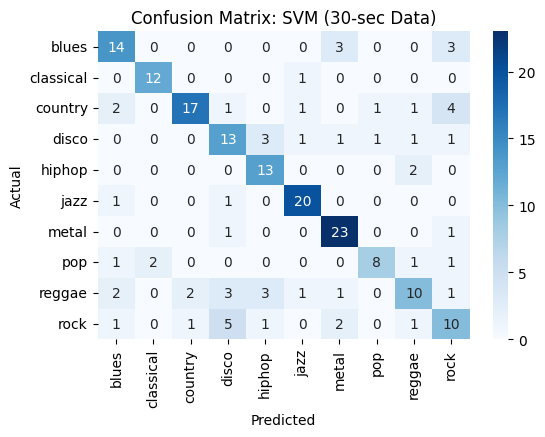


--- TASK 1B & 1C: Training on 3-second features (with Majority Voting) ---

Results for Random Forest on 3-sec Data (Voted):
Classification Accuracy: 0.7400
Macro F1-score: 0.7361


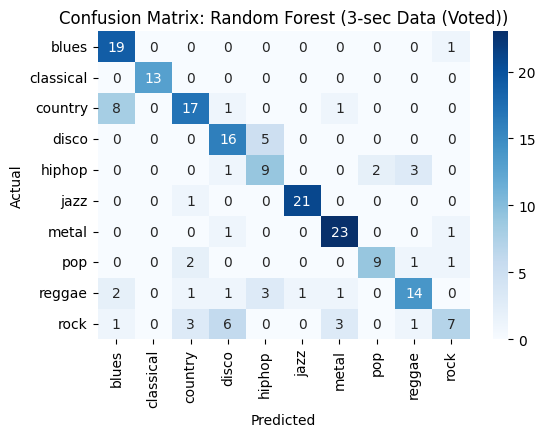


Results for SVM on 3-sec Data (Voted):
Classification Accuracy: 0.7700
Macro F1-score: 0.7587


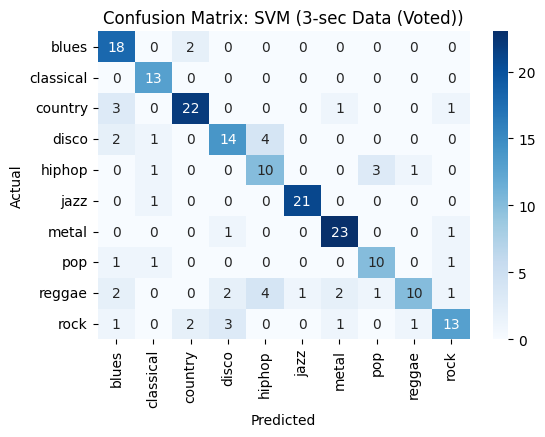


Task 1 Code Execution Complete. Review the output metrics and charts to write your Task 1D comparison.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Phase 0: Data Loading & Preparation
# ==========================================
print("Loading datasets...")
# Load the datasets [cite: 13, 14, 15]
df_30 = pd.read_csv('Data/features_30_sec.csv')
df_3 = pd.read_csv('Data/features_3_sec.csv')

# The GTZAN filenames usually look like "blues.00000.wav" (30s) and "blues.00000.0.wav" (3s).
# We need to extract the base song ID (e.g., "blues.00000") to ensure a strict song-level split.
def extract_song_id(filename):
    parts = filename.split('.')
    return f"{parts[0]}.{parts[1]}"

df_30['song_id'] = df_30['filename'].apply(extract_song_id)
df_3['song_id'] = df_3['filename'].apply(extract_song_id)

# ==========================================
# TASK 1A: Dataset Visualization [cite: 18]
# ==========================================
print("\n--- TASK 1A: Dataset Visualization ---")
print(f"30-sec dataset shape: {df_30.shape} (Samples: {df_30.shape[0]}, Dimensions: {df_30.shape[1]-3})")
print(f"3-sec dataset shape: {df_3.shape} (Samples: {df_3.shape[0]}, Dimensions: {df_3.shape[1]-3})")

# Visualizing Class Distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(y='label', data=df_30, order=df_30['label'].value_counts().index)
plt.title('Class Distribution (30-sec audio-level)')

plt.subplot(1, 2, 2)
sns.countplot(y='label', data=df_3, order=df_3['label'].value_counts().index)
plt.title('Class Distribution (3-sec chunk-level)')
plt.tight_layout()
plt.show()

# ==========================================
# Phase 0.5: Song-Level Train-Test Split
# ==========================================
# Get unique songs
unique_songs = df_30['song_id'].unique()

# Split the unique song IDs into train and test sets (80/20 split)
train_songs, test_songs = train_test_split(unique_songs, test_size=0.2, random_state=42)

# Apply this split to both datasets
train_30 = df_30[df_30['song_id'].isin(train_songs)]
test_30 = df_30[df_30['song_id'].isin(test_songs)]

train_3 = df_3[df_3['song_id'].isin(train_songs)]
test_3 = df_3[df_3['song_id'].isin(test_songs)]

# Separate features (X) and labels (y)
drop_cols = ['filename', 'length', 'label', 'song_id']
X_train_30 = train_30.drop(columns=drop_cols)
y_train_30 = train_30['label']
X_test_30 = test_30.drop(columns=drop_cols)
y_test_30 = test_30['label']

X_train_3 = train_3.drop(columns=drop_cols)
y_train_3 = train_3['label']
X_test_3 = test_3.drop(columns=drop_cols)
y_test_3 = test_3['label']

# Encode labels
le = LabelEncoder()
y_train_30_enc = le.fit_transform(y_train_30)
y_test_30_enc = le.transform(y_test_30)
y_train_3_enc = le.transform(y_train_3)
y_test_3_enc = le.transform(y_test_3)

# Scale features (Crucial for SVM and general performance)
scaler = StandardScaler()
X_train_30_scaled = scaler.fit_transform(X_train_30)
X_test_30_scaled = scaler.transform(X_test_30)

X_train_3_scaled = scaler.fit_transform(X_train_3) # Refit scaler for 3s dataset features
X_test_3_scaled = scaler.transform(X_test_3)

# ==========================================
# Helper Function for Evaluation [cite: 22]
# ==========================================
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nResults for {model_name} on {dataset_name}:")
    print(f"Classification Accuracy: {acc:.4f}")
    print(f"Macro F1-score: {f1:.4f}")

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix: {model_name} ({dataset_name})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# ==========================================
# TASK 1B (i) & 1C: 30-second Feature Models [cite: 20]
# ==========================================
print("\n--- TASK 1B & 1C: Training on 30-second features ---")

# Model 1: Random Forest [cite: 19]
rf_30 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_30.fit(X_train_30_scaled, y_train_30_enc)
rf_preds_30 = rf_30.predict(X_test_30_scaled)
evaluate_model(y_test_30_enc, rf_preds_30, "Random Forest", "30-sec Data")

# Model 2: Support Vector Machine (SVM) [cite: 19]
svm_30 = SVC(kernel='rbf', probability=True, random_state=42)
svm_30.fit(X_train_30_scaled, y_train_30_enc)
svm_preds_30 = svm_30.predict(X_test_30_scaled)
evaluate_model(y_test_30_enc, svm_preds_30, "SVM", "30-sec Data")

# ==========================================
# TASK 1B (ii) & 1C: 3-second Feature Models with Voting [cite: 21]
# ==========================================
print("\n--- TASK 1B & 1C: Training on 3-second features (with Majority Voting) ---")

# Train Models on 3-second chunks [cite: 21]
rf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_3.fit(X_train_3_scaled, y_train_3_enc)

svm_3 = SVC(kernel='rbf', probability=True, random_state=42)
svm_3.fit(X_train_3_scaled, y_train_3_enc)

# Predict on 3-second test chunks
test_3_with_preds = test_3.copy()
test_3_with_preds['rf_pred'] = rf_3.predict(X_test_3_scaled)
test_3_with_preds['svm_pred'] = svm_3.predict(X_test_3_scaled)
test_3_with_preds['true_label'] = y_test_3_enc

# Aggregate segment predictions to obtain a final song-level label using majority voting [cite: 21]
def majority_vote(group, pred_col):
    # Returns the most frequent prediction in the group
    return group[pred_col].mode()[0]

# Group by the original song_id to aggregate the 10 chunks back into 1 prediction per song
aggregated_results = test_3_with_preds.groupby('song_id').apply(
    lambda x: pd.Series({
        'true_label': x['true_label'].iloc[0], # True label is the same for all chunks of a song
        'rf_final_pred': majority_vote(x, 'rf_pred'),
        'svm_final_pred': majority_vote(x, 'svm_pred')
    })
).reset_index()

# Evaluate aggregated results [cite: 22]
evaluate_model(aggregated_results['true_label'], aggregated_results['rf_final_pred'], "Random Forest", "3-sec Data (Voted)")
evaluate_model(aggregated_results['true_label'], aggregated_results['svm_final_pred'], "SVM", "3-sec Data (Voted)")

print("\nTask 1 Code Execution Complete. Review the output metrics and charts to write your Task 1D comparison.")

--- TASK 2: Dimensionality Reduction using PCA ---
Original number of features: 57
Number of features after PCA (retaining 95% variance): 39


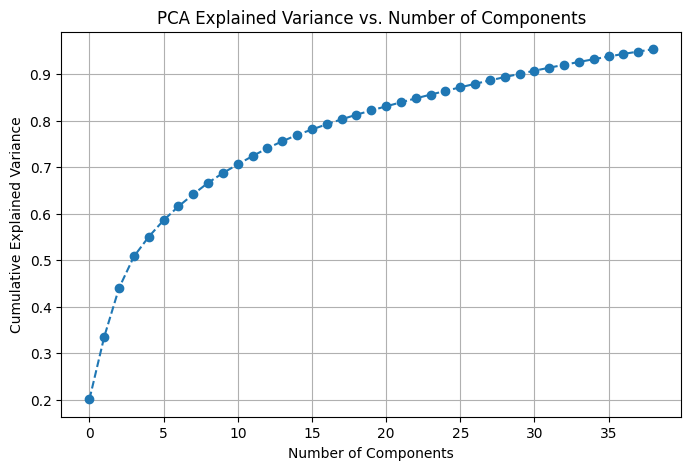


Training SVM on PCA-reduced features...

--- Evaluation Metrics (SVM with PCA) ---
Classification Accuracy: 0.7700
Macro F1-score: 0.7635


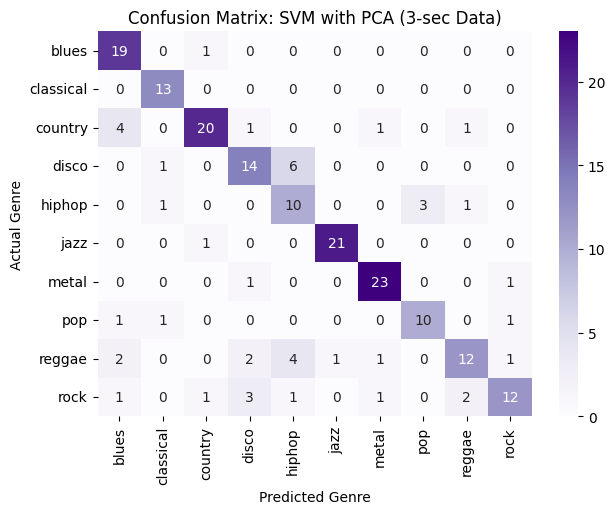

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("--- TASK 2: Dimensionality Reduction using PCA ---")

# ==========================================
# 1. Data Loading & Song-Level Split
# ==========================================
# We will use the 3-second dataset as it generally provides better performance
df_3 = pd.read_csv('Data/features_3_sec.csv')

# Extract base song ID to prevent data leakage (e.g., "blues.00000.0.wav" -> "blues.00000")
df_3['song_id'] = df_3['filename'].apply(lambda x: f"{x.split('.')[0]}.{x.split('.')[1]}")

# Create an 80/20 train-test split based on unique song IDs
unique_songs = df_3['song_id'].unique()
train_songs, test_songs = train_test_split(unique_songs, test_size=0.2, random_state=42)

train_3 = df_3[df_3['song_id'].isin(train_songs)]
test_3 = df_3[df_3['song_id'].isin(test_songs)]

# Separate features and labels
drop_cols = ['filename', 'length', 'label', 'song_id']
X_train = train_3.drop(columns=drop_cols)
y_train = train_3['label']
X_test = test_3.drop(columns=drop_cols)
y_test = test_3['label']

# Encode the text labels into numbers
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Scale features (PCA is highly sensitive to the scale of the data!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. Apply Principal Component Analysis (PCA)
# ==========================================
print(f"Original number of features: {X_train_scaled.shape[1]}")

# We tell PCA to keep 95% of the variance in the data.
# It will automatically figure out how many components (features) are needed to hit 95%.
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Number of features after PCA (retaining 95% variance): {X_train_pca.shape[1]}")

# Visualize the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# ==========================================
# 3. Retrain the Best Model (SVM) & Evaluate
# ==========================================
print("\nTraining SVM on PCA-reduced features...")
# Using the same hyperparameters from Task 1 for a fair comparison
svm_pca = SVC(kernel='rbf', probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train_enc)

# Predict on the test set
test_3_with_preds = test_3.copy()
test_3_with_preds['svm_pca_pred'] = svm_pca.predict(X_test_pca)
test_3_with_preds['true_label'] = y_test_enc

# Aggregate predictions back to the song level using Majority Voting
def majority_vote(group):
    return group['svm_pca_pred'].mode()[0]

aggregated_results = test_3_with_preds.groupby('song_id').apply(
    lambda x: pd.Series({
        'true_label': x['true_label'].iloc[0],
        'final_pred': majority_vote(x)
    })
).reset_index()

# Calculate Evaluation Metrics
y_true_final = aggregated_results['true_label']
y_pred_final = aggregated_results['final_pred']

acc = accuracy_score(y_true_final, y_pred_final)
f1 = f1_score(y_true_final, y_pred_final, average='macro')
cm = confusion_matrix(y_true_final, y_pred_final)

print("\n--- Evaluation Metrics (SVM with PCA) ---")
print(f"Classification Accuracy: {acc:.4f}")
print(f"Macro F1-score: {f1:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: SVM with PCA (3-sec Data)')
plt.ylabel('Actual Genre')
plt.xlabel('Predicted Genre')
plt.show()